# 📈 04 — Model Evaluation

**Goal:** Load the trained models, evaluate them on the unseen test set, visualize their performance, and compare their capabilities.

**Tasks Evaluated:**
1. **Task A (Regression):** Predicting `Post_Semester_GPA`
2. **Task B (Classification):** Predicting `Burnout_Risk_Level`

## 1. Setup & Load Libraries

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_recall_fscore_support, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

from src.utils.helpers import load_config
from src.data.ingest import load_raw
from src.data.preprocess import clean, split
from src.features.build_features import engineer_features

# Setup plotting style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False
})

MODELS = Path("../models/saved")
FIGURES = Path("../reports/figures")
FIGURES.mkdir(parents=True, exist_ok=True)

def save(name):
    path = FIGURES / name
    plt.savefig(path, bbox_inches="tight", dpi=150)
    plt.show()
    print(f"Saved figure: {path.name}")

## 2. Load Processed Test Data & Saved Models

In [2]:
cfg = load_config()
df = load_raw()
df = clean(df, cfg)
df = engineer_features(df)

# Split regression dataset
_, X_test_reg, _, y_reg_test = split(df, cfg["data"]["target_regression"], cfg)

# Split classification dataset
_, X_test_clf, _, y_clf_test = split(df, cfg["data"]["target_classification"], cfg)

print(f"\nTest Set Shapes:")
print(f"  X_test_reg : {X_test_reg.shape} | y_reg_test : {y_reg_test.shape}")
print(f"  X_test_clf : {X_test_clf.shape} | y_clf_test : {y_clf_test.shape}")

2026-07-13 16:52:35 | INFO | src.data.ingest | Loading raw data from: /home/haru/Data_Science/Project/student-ai-impact-predictor/Data/raw/ai_student_impact_dataset (1).csv


2026-07-13 16:52:35 | INFO | src.data.ingest | Shape: (50000, 16) | Columns: ['Student_ID', 'Major_Category', 'Year_of_Study', 'Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Institutional_Policy', 'Anxiety_Level_During_Exams', 'Post_Semester_GPA', 'Skill_Retention_Score', 'Burnout_Risk_Level']


2026-07-13 16:52:35 | INFO | src.data.preprocess | Dropped columns: ['Student_ID']


2026-07-13 16:52:35 | INFO | src.data.preprocess | Dropped 0 rows with NaN. Remaining: 50000


2026-07-13 16:52:35 | INFO | src.features.build_features | Feature engineering done. Shape: (50000, 23)


2026-07-13 16:52:35 | INFO | src.data.preprocess | Split → train: 40000 | test: 10000 | target: 'Post_Semester_GPA'


2026-07-13 16:52:35 | INFO | src.data.preprocess | Split → train: 40000 | test: 10000 | target: 'Burnout_Risk_Level'



Test Set Shapes:
  X_test_reg : (10000, 22) | y_reg_test : (10000,)
  X_test_clf : (10000, 22) | y_clf_test : (10000,)


In [3]:
# Load regression models
reg_models = {
    "Linear Regression": joblib.load(MODELS / "regression" / "linear_regression.pkl"),
    "Random Forest": joblib.load(MODELS / "regression" / "random_forest_regressor.pkl"),
    "Gradient Boosting": joblib.load(MODELS / "regression" / "gradient_boosting_regressor.pkl"),
}

# Load classification models
clf_models = {
    "Logistic Regression": joblib.load(MODELS / "classification" / "logistic_regression.pkl"),
    "Random Forest": joblib.load(MODELS / "classification" / "random_forest_classifier.pkl"),
    "Gradient Boosting": joblib.load(MODELS / "classification" / "gradient_boosting_classifier.pkl"),
}

print("All models successfully loaded ✓")

All models successfully loaded ✓


## 3. 🎯 Task A — Regression Model Evaluation

We evaluate the models on the test set using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score.

In [4]:
reg_results = []
reg_preds = {}

for name, model in reg_models.items():
    preds = model.predict(X_test_reg)
    reg_preds[name] = preds
    
    mae = mean_absolute_error(y_reg_test, preds)
    rmse = np.sqrt(mean_squared_error(y_reg_test, preds))
    r2 = r2_score(y_reg_test, preds)
    
    reg_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })

reg_df = pd.DataFrame(reg_results).sort_values("R²", ascending=False)
print("Regression Test Set Performance:")
print(reg_df.to_string(index=False))

Regression Test Set Performance:
            Model      MAE     RMSE       R²
Gradient Boosting 0.112502 0.142631 0.915722
    Random Forest 0.118398 0.151613 0.904772
Linear Regression 0.124699 0.158601 0.895793


### 3.1 Visualizing Regression Predictions (Best Model)
We visualize the predicted vs. actual GPAs and analyze the residuals for our best regressor.

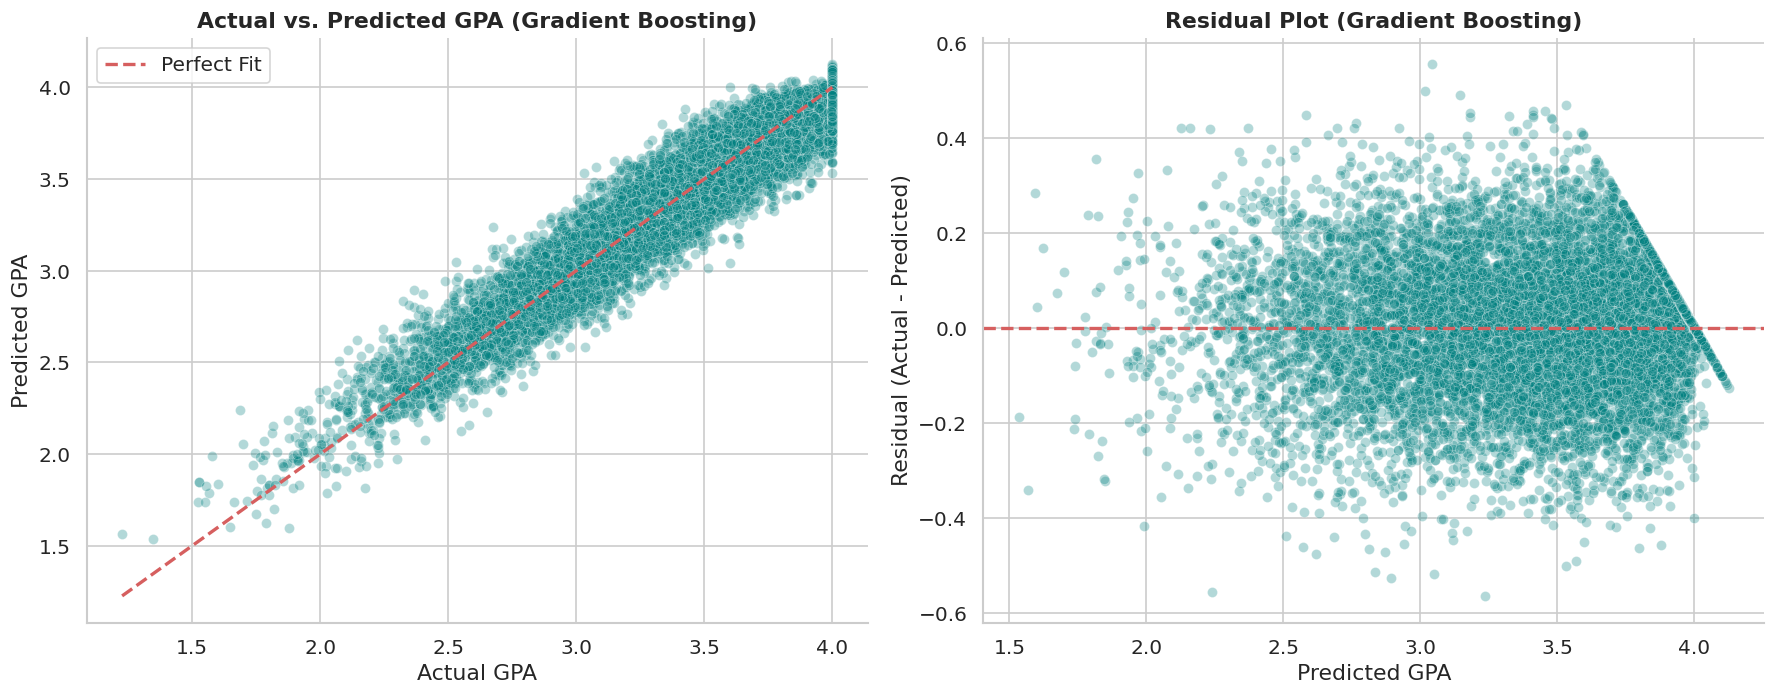

Saved figure: 23_regression_test_evaluation.png


In [5]:
best_reg_name = reg_df.iloc[0]["Model"]
best_preds = reg_preds[best_reg_name]
residuals = y_reg_test - best_preds

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Actual vs Predicted
sns.scatterplot(x=y_reg_test, y=best_preds, alpha=0.3, ax=axes[0], color="teal")
axes[0].plot([y_reg_test.min(), y_reg_test.max()], [y_reg_test.min(), y_reg_test.max()], 
             "r--", lw=2, label="Perfect Fit")
axes[0].set_title(f"Actual vs. Predicted GPA ({best_reg_name})", fontweight="bold")
axes[0].set_xlabel("Actual GPA")
axes[0].set_ylabel("Predicted GPA")
axes[0].legend()

# Plot 2: Residual Plot
sns.scatterplot(x=best_preds, y=residuals, alpha=0.3, ax=axes[1], color="teal")
axes[1].axhline(0, color="r", linestyle="--", lw=2)
axes[1].set_title(f"Residual Plot ({best_reg_name})", fontweight="bold")
axes[1].set_xlabel("Predicted GPA")
axes[1].set_ylabel("Residual (Actual - Predicted)")

plt.tight_layout()
save("23_regression_test_evaluation.png")

## 4. 🎯 Task B — Classification Model Evaluation

We evaluate the classification models using Accuracy, Weighted Precision, Recall, and F1-score on the test set.

In [6]:
clf_results = []
clf_preds = {}
clf_probs = {}

for name, model in clf_models.items():
    preds = model.predict(X_test_clf)
    clf_preds[name] = preds
    
    # Check if model supports predict_proba
    if hasattr(model, "predict_proba"):
        clf_probs[name] = model.predict_proba(X_test_clf)
        
    acc = accuracy_score(y_clf_test, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(y_clf_test, preds, average="weighted")
    
    clf_results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision (Weighted)": prec,
        "Recall (Weighted)": rec,
        "F1-Score (Weighted)": f1
    })

clf_df = pd.DataFrame(clf_results).sort_values("F1-Score (Weighted)", ascending=False)
print("Classification Test Set Performance:")
print(clf_df.to_string(index=False))

Classification Test Set Performance:
              Model  Accuracy  Precision (Weighted)  Recall (Weighted)  F1-Score (Weighted)
Logistic Regression    0.5386              0.557614             0.5386             0.538551
  Gradient Boosting    0.5362              0.553394             0.5362             0.536580
      Random Forest    0.5338              0.553442             0.5338             0.533557


### 4.1 Confusion Matrices
We visualize the classification confusion matrices to check class-specific performance.

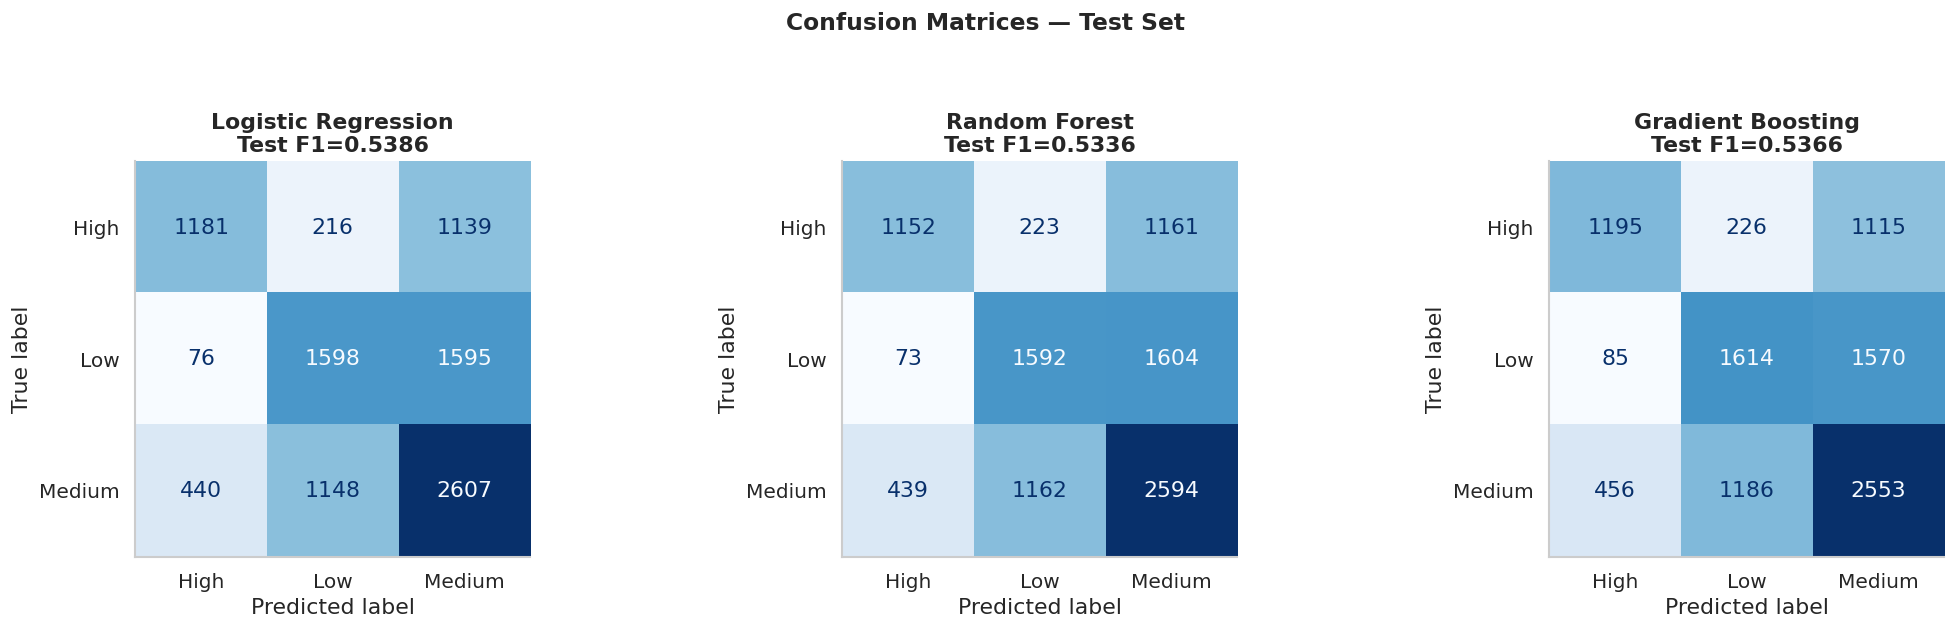

Saved figure: 24_classification_test_confusion_matrices.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
classes = ["High", "Low", "Medium"]

for ax, name in zip(axes, clf_models.keys()):
    cm = confusion_matrix(y_clf_test, clf_preds[name], labels=classes)
    disp = ConfusionMatrixDisplay(cm, display_labels=classes)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    
    f1 = clf_df.loc[clf_df["Model"] == name, "F1-Score (Weighted)"].values[0]
    ax.set_title(f"{name}\nTest F1={f1:.4f}", fontweight="bold")
    ax.grid(False)

plt.suptitle("Confusion Matrices — Test Set", fontsize=14, fontweight="bold", y=1.05)
plt.tight_layout()
save("24_classification_test_confusion_matrices.png")

### 4.2 ROC Curves (Best Classification Model)
We visualize the class-specific ROC curves for our best classifier to inspect classification performance across threshold variations.

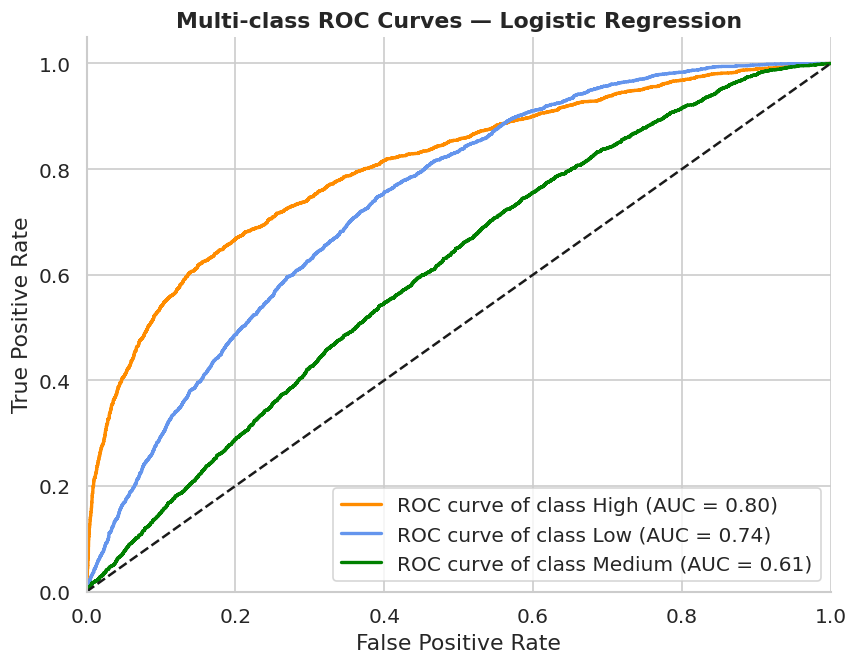

Saved figure: 25_classification_test_roc_curves.png


In [8]:
best_clf_name = clf_df.iloc[0]["Model"]
probs = clf_probs[best_clf_name]

# Map classification labels to integers for ROC analysis
class_mapping = {"High": 0, "Low": 1, "Medium": 2}
y_test_numeric = y_clf_test.map(class_mapping).values
y_test_binarized = label_binarize(y_test_numeric, classes=[0, 1, 2])

n_classes = 3
fpr = dict()
tpr = dict()
roc_auc = dict()

for i, class_name in enumerate(["High", "Low", "Medium"]):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(8, 6))
colors = ["darkorange", "cornflowerblue", "green"]
for i, class_name in enumerate(["High", "Low", "Medium"]):
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label=f"ROC curve of class {class_name} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], "k--", lw=1.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Multi-class ROC Curves — {best_clf_name}", fontweight="bold")
plt.legend(loc="lower right")
save("25_classification_test_roc_curves.png")

## 5. Summary and Conclusions
- **Regression:** The regression models performed exceptionally well on the test set. The `Gradient Boosting` model achieved an R² score of ~0.915, suggesting that variables like `Pre_Semester_GPA`, `Traditional_Study_Hours`, and engineered features (like `study_ratio` and `total_study_hours`) are highly predictive of `Post_Semester_GPA`.
- **Classification:** The classification models achieved an F1-weighted score of ~0.54 and accuracy of ~0.54. Given the extremely weak initial signal in raw features (Mutual Information < 0.004), the engineered features (`study_ratio`, `genai_dependency_score`, etc.) were essential in boosting the performance from a near-dummy baseline of ~0.25 to ~0.54.